In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

In [4]:
DATA_DIR = Path('../data')
orders_clean = pd.read_csv(DATA_DIR / 'orders_clean.csv', parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date'])
orders_clean = pd.DataFrame(orders_clean)
orders_clean.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,price,freight_value,total_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,28.62


In [41]:
rfm = orders_clean.groupby('customer_unique_id').agg({
    'order_purchase_timestamp'  : 'max',
    'total_value':'sum',
    'order_id': 'count'
}
)
rfm.head()

,order_purchase_timestamp,total_value,order_id
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,1
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,1
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,1
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,1
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,1


In [42]:
rfm.reset_index(inplace=True)
rfm.rename(columns={'total_value': 'monetary', 'order_purchase_timestamp': 'last_purchase','order_id': 'frequency'},inplace=True)
rfm.head()

,customer_unique_id,last_purchase,monetary,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,1


In [43]:
reference_date = max(rfm['last_purchase'])
rfm['recency_days'] = (reference_date - rfm['last_purchase']).dt.days
rfm.head()

,customer_unique_id,last_purchase,monetary,frequency,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,1,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,1,114
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,1,536
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,1,320
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,1,287


In [48]:
rfm['r_score'] = pd.qcut(rfm['recency_days'], q=5, labels = ['5','4', '3', '2', '1'])
rfm['f_score'] = pd.cut(rfm['frequency'], labels = ['1','2', '3', '4', '5'], duplicates='drop',bins = [0, 1, 2, 3, 5, 15])
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels = ['1','2', '3', '4', '5'])
rfm.head()

,customer_unique_id,last_purchase,monetary,frequency,recency_days,r_score,f_score,m_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,1,111,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,1,114,4,1,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,1,536,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,1,320,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,1,287,2,1,4


In [54]:
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']
rfm.head()

,customer_unique_id,last_purchase,monetary,frequency,recency_days,r_score,f_score,m_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,1,111,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,1,114,4,1,1,6
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,1,536,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,1,320,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,1,287,2,1,4,7


In [58]:
rfm['segment'] = pd.cut(rfm['rfm_score'], labels = ['Lost','At Risk', 'Loyal', 'Champions'], bins = [1, 5, 8, 12, 15])
rfm.head()

,customer_unique_id,last_purchase,monetary,frequency,recency_days,r_score,f_score,m_score,rfm_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,141.90,1,111,4,1,4,9,Loyal
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,27.19,1,114,4,1,1,6,At Risk
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,1,536,1,1,2,4,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,1,320,2,1,1,4,Lost
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,1,287,2,1,4,7,At Risk


In [64]:
segment_counts = rfm['segment'].value_counts()

из приятного - примерно четверть клиентов лояльна, ещё половина в рисковой позиции, но не потеряна - значит можно попытаться их вернуть. из неприятного - четверть клиентов потеряна, а чемпионов вообще всего 68

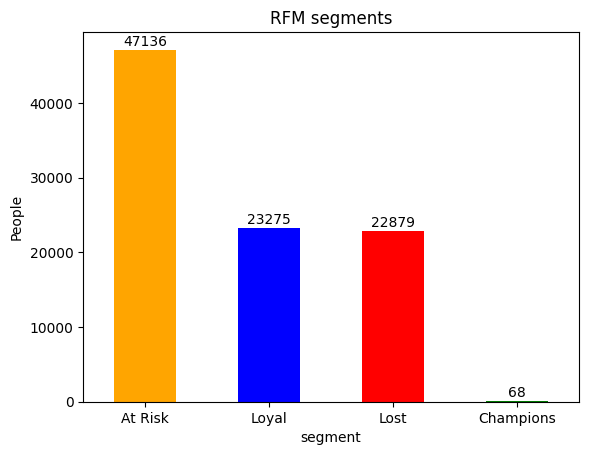

In [78]:
colors = ['orange', 'blue', 'red', 'green']
# orders = ['Lost', 'At Risk', 'Loyal', 'Champions']
seg = segment_counts.plot(kind='bar', x='Segment', y='People', legend=False, color=colors)

seg.bar_label(seg.containers[0], padding=1)

plt.xticks(rotation=0)
plt.ylabel('People')
plt.title('RFM segments')
plt.show()

In [80]:
rfm.groupby('segment')[['recency_days','frequency','monetary']].mean()

,recency_days,frequency,monetary
segment,,,
Lost,377.357402,1.002098,61.455080
At Risk,233.219620,1.016760,153.341864
Loyal,106.939248,1.088894,289.478771
Champions,70.573529,4.132353,708.860294


champions недавно покупали товары(среднее - 70 дней назад), на большую сумму(в 3 раза больше, чем у loyal и в 11 раз больше, чем у lost), при этом делали это в 4 раза чаще
у lost и at risk самая большая разница в 2,5 раза замечтается в сумме покупки
monetary надо увеличить чтобы перейти в champions из loyal